In [1]:
pip install findspark pyspark

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from pyspark.sql import SparkSession
spark = SparkSession.builder \
        .appName("MyPySparkApp") \
        .master("local[*]") \
        .getOrCreate()



In [3]:
from pyspark.sql.functions import *
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import sum

In [4]:
import findspark
findspark.init()

In [5]:
#Need to upload the file manually as I have prepared the notebook on google colab
#from google.colab import files
#uploaded = files.upload()

In [6]:
data = spark.read.csv("D:/Pyspark/project-assignment/dataset/nyc-jobs.csv", header=True, inferSchema = True, multiLine=True, quote='"',  escape='"')
data.printSchema()

root
 |-- Job ID: integer (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: integer (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: double (nullable = true)
 |-- Salary Range To: double (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: string (nullable = true)
 |-- Additional Information: string (nullable = true)
 |-- To Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work Locat

In [7]:
data.show(5)
data.columns

+------+--------------------+------------+--------------+--------------------+--------------------+-------------+-----+--------------------+-----------------------------+-----------------+---------------+----------------+--------------------+--------------------+--------------------+-------------------------+--------------------+----------------------+--------------------+-----------+---------------+-------------------+---------------------+-------------------+----------+-------------------+-------------------+
|Job ID|              Agency|Posting Type|# Of Positions|      Business Title| Civil Service Title|Title Code No|Level|        Job Category|Full-Time/Part-Time indicator|Salary Range From|Salary Range To|Salary Frequency|       Work Location|  Division/Work Unit|     Job Description|Minimum Qual Requirements|    Preferred Skills|Additional Information|            To Apply|Hours/Shift|Work Location 1|Recruitment Contact|Residency Requirement|       Posting Date|Post Until|    Pos

['Job ID',
 'Agency',
 'Posting Type',
 '# Of Positions',
 'Business Title',
 'Civil Service Title',
 'Title Code No',
 'Level',
 'Job Category',
 'Full-Time/Part-Time indicator',
 'Salary Range From',
 'Salary Range To',
 'Salary Frequency',
 'Work Location',
 'Division/Work Unit',
 'Job Description',
 'Minimum Qual Requirements',
 'Preferred Skills',
 'Additional Information',
 'To Apply',
 'Hours/Shift',
 'Work Location 1',
 'Recruitment Contact',
 'Residency Requirement',
 'Posting Date',
 'Post Until',
 'Posting Updated',
 'Process Date']

In [8]:
data = data.withColumn(
    "Posting Date",
    expr("try_cast(`Posting Date` as date)")
)

In [9]:
data.printSchema()

root
 |-- Job ID: integer (nullable = true)
 |-- Agency: string (nullable = true)
 |-- Posting Type: string (nullable = true)
 |-- # Of Positions: integer (nullable = true)
 |-- Business Title: string (nullable = true)
 |-- Civil Service Title: string (nullable = true)
 |-- Title Code No: string (nullable = true)
 |-- Level: string (nullable = true)
 |-- Job Category: string (nullable = true)
 |-- Full-Time/Part-Time indicator: string (nullable = true)
 |-- Salary Range From: double (nullable = true)
 |-- Salary Range To: double (nullable = true)
 |-- Salary Frequency: string (nullable = true)
 |-- Work Location: string (nullable = true)
 |-- Division/Work Unit: string (nullable = true)
 |-- Job Description: string (nullable = true)
 |-- Minimum Qual Requirements: string (nullable = true)
 |-- Preferred Skills: string (nullable = true)
 |-- Additional Information: string (nullable = true)
 |-- To Apply: string (nullable = true)
 |-- Hours/Shift: string (nullable = true)
 |-- Work Locat

# **Detailed Analysis of Dataset**

#1. Provide a detailed analysis of source data: Column values

In [10]:
num_cols = [] #using a list to store appended values
catg_cols = []
date_cols = []

for field in data.schema.fields:
    if isinstance(field.dataType, (IntegerType, DoubleType)):
        num_cols.append(field.name)
    elif isinstance(field.dataType, DateType):
        date_cols.append(field.name)
    else:
        catg_cols.append(field.name)

print("Total Numerical Columns", num_cols)
print("Total Categorical Columns:", catg_cols)
print("Total Date Columns:", date_cols)

Total Numerical Columns ['Job ID', '# Of Positions', 'Salary Range From', 'Salary Range To']
Total Categorical Columns: ['Agency', 'Posting Type', 'Business Title', 'Civil Service Title', 'Title Code No', 'Level', 'Job Category', 'Full-Time/Part-Time indicator', 'Salary Frequency', 'Work Location', 'Division/Work Unit', 'Job Description', 'Minimum Qual Requirements', 'Preferred Skills', 'Additional Information', 'To Apply', 'Hours/Shift', 'Work Location 1', 'Recruitment Contact', 'Residency Requirement', 'Post Until', 'Posting Updated', 'Process Date']
Total Date Columns: ['Posting Date']


#**Columns Stats** 

In [11]:
#numerical columns distict values
print("#### num_cols count - {} ####".format(len(num_cols)))
for col in num_cols :
    print("{} have distinct {}".format(col,data.select(col).distinct().count()))
    print("Mean of {} is {}".format(col,data.select(col).describe().show()) )
    
print("=====================================================")

print("#### catg_cols count - {} ####".format(len(catg_cols)))
#category columns distinct values
for col in catg_cols :
    print("{} have distinct {}".format(col,data.select(col).distinct().count()))    
print("=====================================================")


print("#### date_cols count - {} ####".format(len(date_cols)))
# distinct dates 
for col in date_cols :
    print("{} have distinct {}".format(col,data.select(col).distinct().count()))      

#### num_cols count - 4 ####
Job ID have distinct 1661
+-------+-----------------+
|summary|           Job ID|
+-------+-----------------+
|  count|             2946|
|   mean|384821.5631364562|
| stddev|53075.33897715372|
|    min|            87990|
|    max|           426238|
+-------+-----------------+

Mean of Job ID is None
# Of Positions have distinct 34
+-------+------------------+
|summary|    # Of Positions|
+-------+------------------+
|  count|              2946|
|   mean|2.4959266802443993|
| stddev|  9.28131282646684|
|    min|                 1|
|    max|               200|
+-------+------------------+

Mean of # Of Positions is None
Salary Range From have distinct 519
+-------+-----------------+
|summary|Salary Range From|
+-------+-----------------+
|  count|             2946|
|   mean|58904.13979385607|
| stddev|26986.57593579136|
|    min|              0.0|
|    max|         218587.0|
+-------+-----------------+

Mean of Salary Range From is None
Salary Range To have 

*Count of amployees with different salary frequecy*

In [12]:
print(data.groupBy("Salary Frequency").count().show())

+----------------+-----+
|Salary Frequency|count|
+----------------+-----+
|          Annual| 2712|
|           Daily|   39|
|          Hourly|  195|
+----------------+-----+

None


# **KPI**

#1. Whats the number of jobs posting per category (Top 10)?


In [13]:
from pyspark.sql.functions import sum, col, desc
jobs_posting = data.groupBy(col("Job Category")).agg(sum(col("# Of Positions")).alias("Total Positions")).orderBy(desc("Total Positions")).limit(10)
jobs_posting.show(truncate=False)

+-----------------------------------------+---------------+
|Job Category                             |Total Positions|
+-----------------------------------------+---------------+
|Public Safety, Inspections, & Enforcement|1407           |
|Building Operations & Maintenance        |1249           |
|Engineering, Architecture, & Planning    |762            |
|Legal Affairs                            |515            |
|Technology, Data & Innovation            |405            |
|Health                                   |358            |
|Administration & Human Resources         |330            |
|Finance, Accounting, & Procurement       |275            |
|Maintenance & Operations                 |212            |
|Policy, Research & Analysis              |200            |
+-----------------------------------------+---------------+



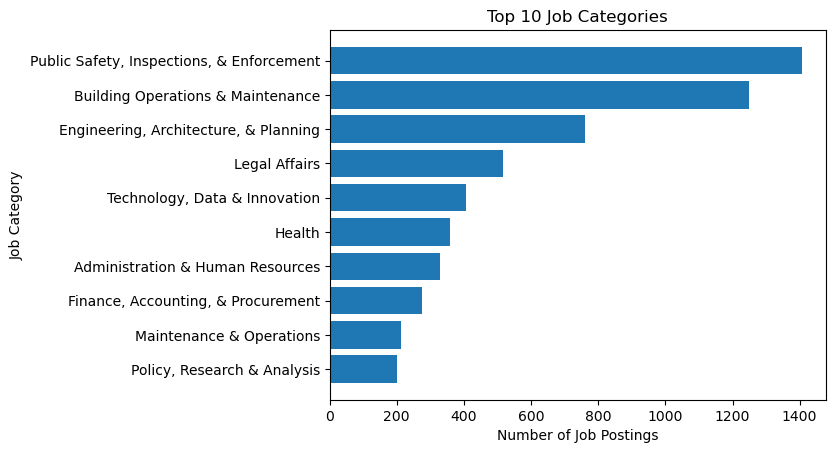

In [14]:
top_job_catg = jobs_posting.toPandas()

plt.figure()
plt.barh(top_job_catg["Job Category"], top_job_catg["Total Positions"])
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Category")
plt.title("Top 10 Job Categories")
plt.gca().invert_yaxis()
plt.show()

#*Count of job category with different salary frequencies*

In [15]:
# Pivot salary frequency counts for top job categories
from pyspark.sql import functions as F
pivot_df = data.groupBy("Job Category").pivot("Salary Frequency").agg(F.sum(F.col("# Of Positions")))
pivot_df = pivot_df.orderBy(F.desc("Annual")) # Order by most common frequency, adjust as needed
top_pivot = pivot_df.limit(10)
top_pivot.show(truncate=False)

+-----------------------------------------+------+-----+------+
|Job Category                             |Annual|Daily|Hourly|
+-----------------------------------------+------+-----+------+
|Public Safety, Inspections, & Enforcement|799   |NULL |608   |
|Engineering, Architecture, & Planning    |756   |2    |4     |
|Building Operations & Maintenance        |600   |254  |395   |
|Legal Affairs                            |511   |NULL |4     |
|Technology, Data & Innovation            |372   |NULL |33    |
|Administration & Human Resources         |272   |NULL |58    |
|Finance, Accounting, & Procurement       |249   |NULL |26    |
|Health                                   |171   |NULL |187   |
|Policy, Research & Analysis              |171   |1    |28    |
|Social Services                          |131   |NULL |2     |
+-----------------------------------------+------+-----+------+



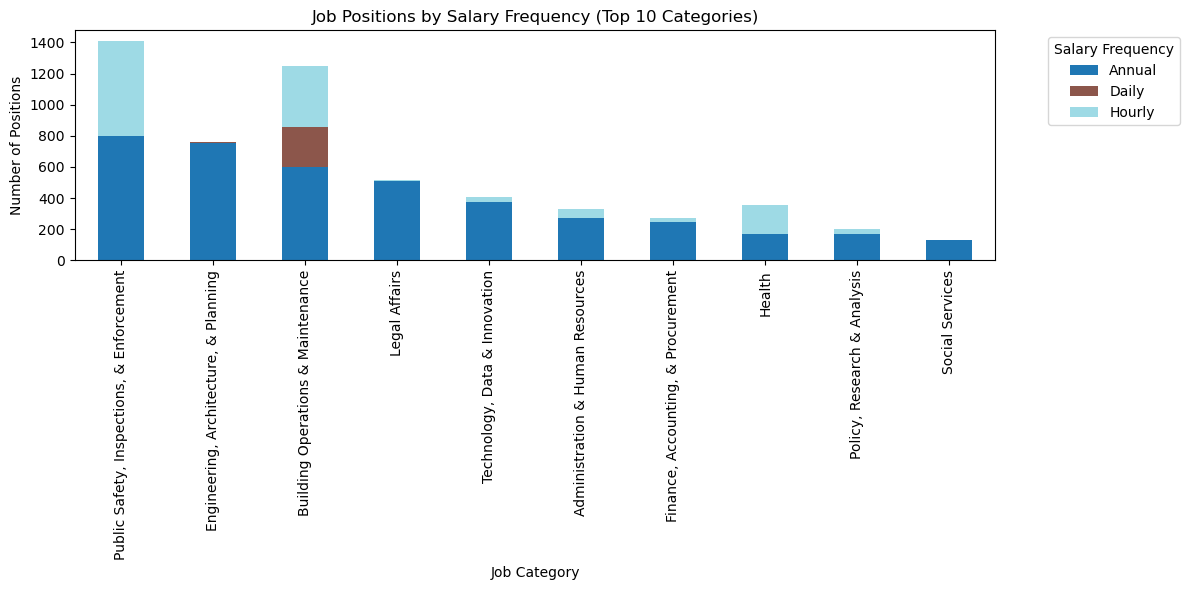

In [16]:
# Plot stacked bar chart for salary frequency counts by job category using matplotlib
import matplotlib.pyplot as plt
pivot_pd = top_pivot.toPandas()
pivot_pd = pivot_pd.set_index('Job Category')
salary_freq_cols = [col for col in pivot_pd.columns if col != 'Total']
pivot_pd[salary_freq_cols].plot(kind='bar', stacked=True, figsize=(12,6), cmap='tab20')
plt.xlabel('Job Category')
plt.ylabel('Number of Positions')
plt.title('Job Positions by Salary Frequency (Top 10 Categories)')
plt.legend(title='Salary Frequency', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#2. Salary Distribution per Job Category

In [17]:
salary_data = data.withColumn(
    "Average Salary",
    (col("Salary Range From") + col("Salary Range To")) / 2
)

salary_by_category = salary_data.groupBy("Job Category") \
    .agg(avg("Average Salary").alias("Avg Salary")) \
    .orderBy(desc("Avg Salary"))

salary_by_category.show(truncate = True)

+--------------------+------------------+
|        Job Category|        Avg Salary|
+--------------------+------------------+
|Administration & ...|          218587.0|
|Engineering, Arch...|          198518.0|
|Engineering, Arch...|          196042.5|
|Health Policy, Re...|          128694.5|
|Engineering, Arch...|          128247.5|
|Engineering, Arch...|          128247.5|
|Communications & ...|          125000.0|
|Administration & ...|          118287.0|
|Constituent Servi...|116900.33333333333|
|Constituent Servi...|          103680.5|
|Technology, Data ...|          96373.45|
|Administration & ...|           95000.0|
|Administration & ...|           92500.0|
|Administration & ...|         91497.575|
|Administration & ...| 91174.22222222222|
|Administration & ...|           91000.0|
|Administration & ...|           90000.0|
|Engineering, Arch...| 89857.43548387097|
|Engineering, Arch...|           89730.0|
|Legal Affairs Pol...| 88898.66666666667|
+--------------------+------------

In [18]:
from pyspark.sql.functions import when, count

salary_bins = salary_data.withColumn(
    "Salary_Bin",
    when(col("Average Salary") < 50000, "<50K")
    .when((col("Average Salary") >= 50000) & (col("Average Salary") < 70000), "50K-70K")
    .when((col("Average Salary") >= 70000) & (col("Average Salary") < 90000), "70K-90K")
    .otherwise("90K+")
)

salary_distribution = salary_bins.groupBy("Job Category", "Salary_Bin") \
    .agg(count("*").alias("Employee_Count")) \
    .orderBy("Job Category", "Salary_Bin")

salary_distribution.show(truncate=True)

+--------------------+----------+--------------+
|        Job Category|Salary_Bin|Employee_Count|
+--------------------+----------+--------------+
|                NULL|   50K-70K|             1|
|                NULL|      90K+|             1|
|Administration & ...|   50K-70K|            47|
|Administration & ...|   70K-90K|            10|
|Administration & ...|      90K+|            20|
|Administration & ...|      <50K|            57|
|Administration & ...|   50K-70K|             1|
|Administration & ...|   70K-90K|             1|
|Administration & ...|      90K+|             2|
|Administration & ...|      <50K|             3|
|Administration & ...|   50K-70K|             3|
|Administration & ...|      <50K|             2|
|Administration & ...|      90K+|             1|
|Administration & ...|   70K-90K|             2|
|Administration & ...|   70K-90K|             2|
|Administration & ...|      <50K|             2|
|Administration & ...|   50K-70K|             1|
|Administration & ..

In [19]:
from pyspark.sql.functions import count, min, max, avg

salary_summary = salary_data.groupBy("Job Category") \
    .agg(
        count("*").alias("Employee_Count"),
        avg("Average Salary").alias("Avg Salary"),
        min("Average Salary").alias("Min Salary"),
        max("Average Salary").alias("Max Salary")
    ).orderBy(desc("Avg Salary"))

salary_summary.show(truncate=True)

+--------------------+--------------+------------------+----------+----------+
|        Job Category|Employee_Count|        Avg Salary|Min Salary|Max Salary|
+--------------------+--------------+------------------+----------+----------+
|Administration & ...|             2|          218587.0|  218587.0|  218587.0|
|Engineering, Arch...|             2|          198518.0|  198518.0|  198518.0|
|Engineering, Arch...|             4|          196042.5|  182500.0|  209585.0|
|Health Policy, Re...|             4|          128694.5|   94889.0|  162500.0|
|Engineering, Arch...|             2|          128247.5|  128247.5|  128247.5|
|Engineering, Arch...|             2|          128247.5|  128247.5|  128247.5|
|Communications & ...|             2|          125000.0|  125000.0|  125000.0|
|Administration & ...|             2|          118287.0|  118287.0|  118287.0|
|Constituent Servi...|             6|116900.33333333333|   58500.0|  217201.0|
|Constituent Servi...|             2|          10368

In [20]:
from pyspark.sql.functions import avg, min, max, stddev, expr

salary_analytics = salary_data.groupBy("Job Category") \
    .agg(
        count("*").alias("Total Employees"),
        avg("Average Salary").alias("Avg Salary"),
        expr("percentile_approx(`Average Salary`, 0.5)").alias("Median Salary"),
        min("Average Salary").alias("Min Salary"),
        max("Average Salary").alias("Max Salary"),
        stddev("Average Salary").alias("Salary StdDev")
    )

salary_analytics.show(truncate=True)

+--------------------+---------------+-----------------+-------------+----------+----------+------------------+
|        Job Category|Total Employees|       Avg Salary|Median Salary|Min Salary|Max Salary|     Salary StdDev|
+--------------------+---------------+-----------------+-------------+----------+----------+------------------+
|                NULL|              2|          82661.0|      53945.0|   53945.0|  111377.0|  40610.5566571058|
|Administration & ...|            134|53755.85496492537|      53094.0|      16.4|  132205.0| 31696.20854953296|
|Administration & ...|              7|61430.71428571428|      51418.5|   37979.5|   94970.0| 25505.01521900014|
|Administration & ...|              3|          69040.5|      69040.5|   69040.5|   69040.5|               0.0|
|Administration & ...|              2|          47864.5|      47864.5|   47864.5|   47864.5|               0.0|
|Administration & ...|              1|          95000.0|      95000.0|   95000.0|   95000.0|            

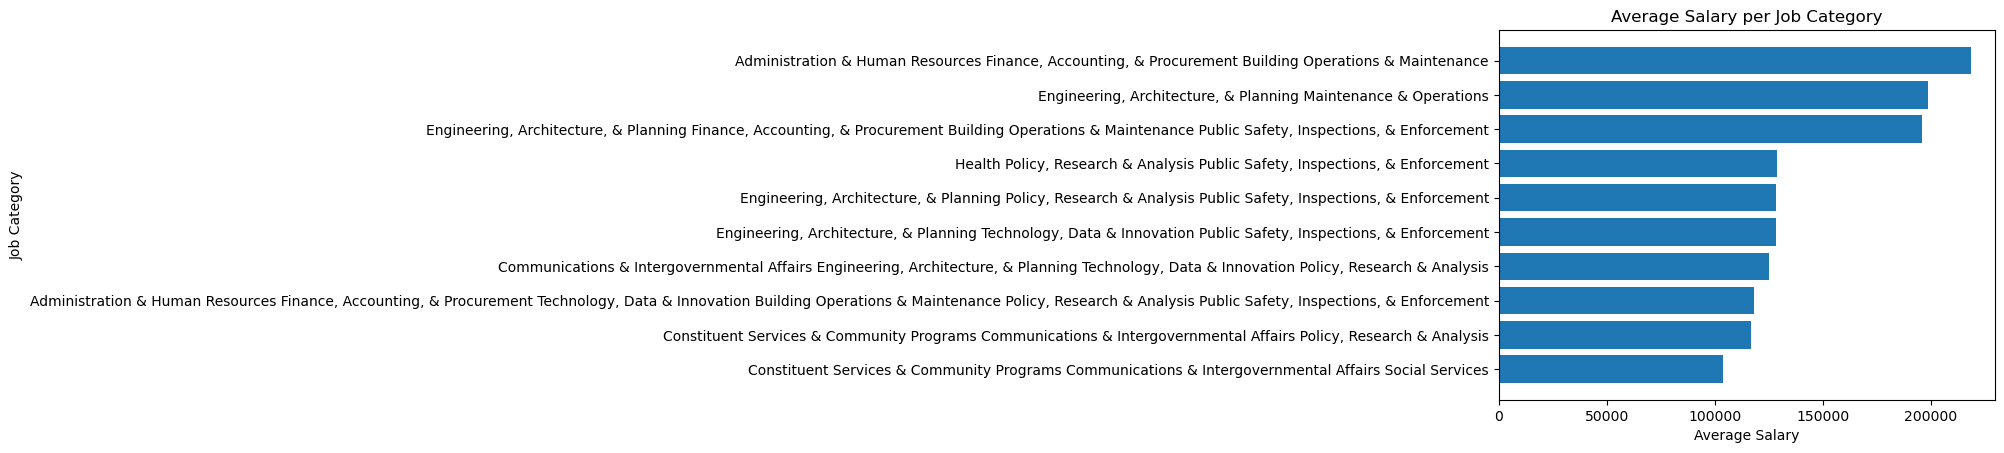

In [21]:
salary_pd = salary_by_category.limit(10).toPandas()

plt.figure()
plt.barh(salary_pd["Job Category"], salary_pd["Avg Salary"])
plt.xlabel("Average Salary")
plt.ylabel("Job Category")
plt.title("Average Salary per Job Category")
plt.gca().invert_yaxis()
plt.show()

In [22]:
salary_summary_pd = salary_analytics.limit(10).toPandas()

C:\Users\phani\AppData\Local\Temp\ipykernel_17112\4000631948.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


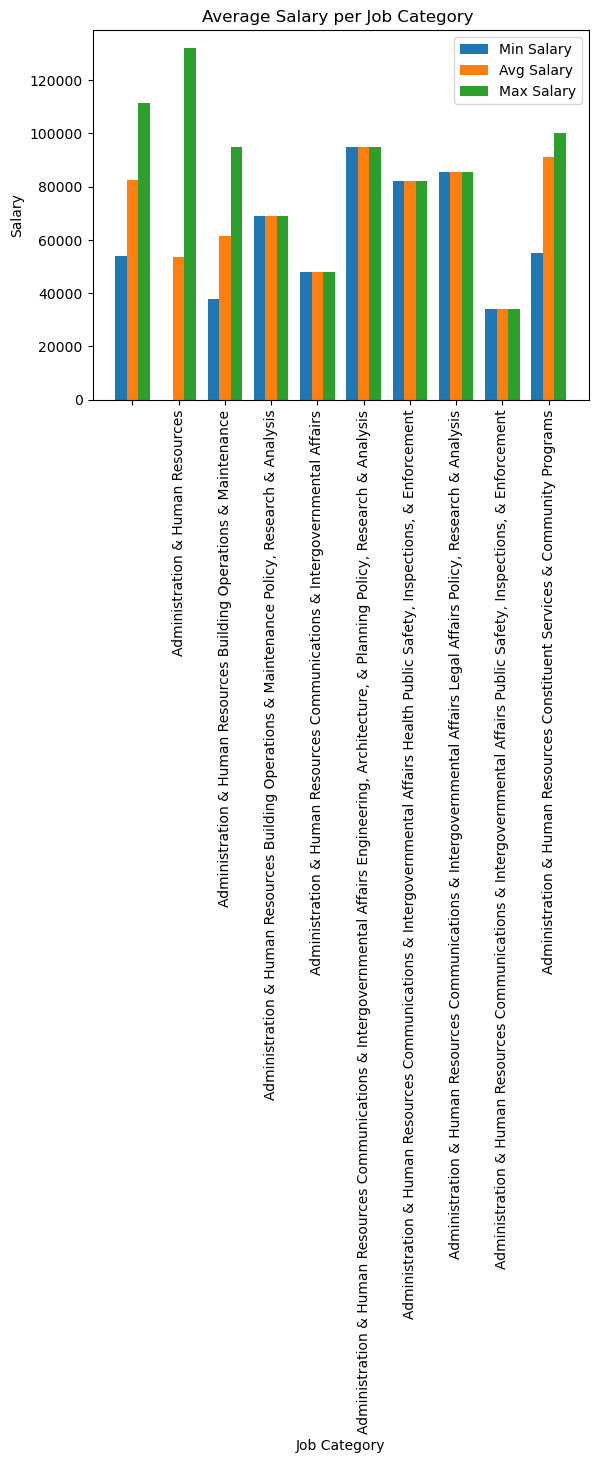

In [26]:
import matplotlib.pyplot as plt
import numpy as np

categories = salary_summary_pd["Job Category"]

x = np.arange(len(categories))
width = 0.25

plt.figure()

plt.bar(x - width, salary_summary_pd["Min Salary"], width, label="Min Salary")
plt.bar(x, salary_summary_pd["Avg Salary"], width, label="Avg Salary")
plt.bar(x + width, salary_summary_pd["Max Salary"], width, label="Max Salary")

plt.xticks(x, categories, rotation=90)
plt.xlabel("Job Category")
plt.ylabel("Salary")
plt.title("Average Salary per Job Category ")
plt.legend()

plt.tight_layout()
plt.show()

#3. Correlation: Higher Degree vs Salary    

In [24]:
degree_df = salary_data.withColumn(
    "Has_Higher_Degree",
    when(col("Minimum Qual Requirements").rlike("Bachelor|Master|PhD"), 1).otherwise(0) #
)

degree_df.stat.corr("Has_Higher_Degree", "Average Salary")

0.0991540245867495

*There is no Minimum Qual Requirements for  PhD due to this  Division by zero*

In [27]:
degree_df = salary_data.withColumn(
    "Has_Higher_Degree",
    when(col("Minimum Qual Requirements").rlike("PhD"), 1).otherwise(0)#
)

degree_df.stat.corr("Has_Higher_Degree", "Average Salary")

{"ts": "2026-02-26 15:51:40.449", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[DIVIDE_BY_ZERO] Division by zero. Use `try_divide` to tolerate divisor being 0 and return NULL instead. If necessary set \"spark.sql.ansi.enabled\" to \"false\" to bypass this error. SQLSTATE: 22012", "context": {"file": "java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)", "line": "", "fragment": "corr", "errorClass": "DIVIDE_BY_ZERO"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o438.corr.\n: org.apache.spark.SparkArithmeticException: [DIVIDE_BY_ZERO] Division by zero. Use `try_divide` to tolerate divisor being 0 and return NULL instead. If necessary set \"spark.sql.ansi.enabled\" to \"false\" to bypass this error. SQLSTATE: 22012\n== DataFrame ==\n\"corr\" was called from\njava.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)\n\r\n\tat org.apache.spark.sql.errors.QueryExecutionErrors$.divideByZe

ArithmeticException: [DIVIDE_BY_ZERO] Division by zero. Use `try_divide` to tolerate divisor being 0 and return NULL instead. If necessary set "spark.sql.ansi.enabled" to "false" to bypass this error. SQLSTATE: 22012
== DataFrame ==
"corr" was called from
java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)


In [28]:
from pyspark.sql.window import Window

windowSpec = Window.partitionBy("Agency").orderBy(desc("Average Salary"))

highest_salary = degree_df.withColumn("rank", rank().over(windowSpec)) \
    .filter(col("rank") == 1) \
    .select("Agency", "Business Title", "Average Salary")

highest_salary.show(truncate=False)

+-----------------------------+-----------------------------------------------------+--------------+
|Agency                       |Business Title                                       |Average Salary|
+-----------------------------+-----------------------------------------------------+--------------+
|ADMIN FOR CHILDREN'S SVCS    |Assistant Commissioner                               |117474.5      |
|ADMIN TRIALS AND HEARINGS    |Assistant General Counsel                            |90000.0       |
|ADMIN TRIALS AND HEARINGS    |Assistant General Counsel                            |90000.0       |
|BOARD OF CORRECTION          |IT Systems Support Engineer                          |96222.5       |
|BOARD OF CORRECTION          |IT Systems Support Engineer                          |96222.5       |
|BOROUGH PRESIDENT-QUEENS     |Engineering                                          |80526.5       |
|BOROUGH PRESIDENT-QUEENS     |Engineering                                          |80526.

#Identify Top-Paying Positions per Unit

In [29]:
windowSpec_unit = Window.partitionBy("Agency").orderBy(desc("Average Salary"))

top_positions = salary_data.withColumn("rank", rank().over(windowSpec_unit)) \
    .filter(col("rank") <= 3) \
    .select("Agency", "Business Title", "Average Salary", "rank") \
    .orderBy("Agency", "rank")

top_positions.show(truncate=False)

+-----------------------------+---------------------------------+--------------+----+
|Agency                       |Business Title                   |Average Salary|rank|
+-----------------------------+---------------------------------+--------------+----+
|ADMIN FOR CHILDREN'S SVCS    |Assistant Commissioner           |117474.5      |1   |
|ADMIN FOR CHILDREN'S SVCS    |Deputy Budget Director           |107734.0      |2   |
|ADMIN FOR CHILDREN'S SVCS    |Deputy Budget Director           |107734.0      |2   |
|ADMIN TRIALS AND HEARINGS    |Assistant General Counsel        |90000.0       |1   |
|ADMIN TRIALS AND HEARINGS    |Assistant General Counsel        |90000.0       |1   |
|ADMIN TRIALS AND HEARINGS    |Facilities & Security Coordinator|40008.0       |3   |
|ADMIN TRIALS AND HEARINGS    |Facilities & Security Coordinator|40008.0       |3   |
|BOARD OF CORRECTION          |IT Systems Support Engineer      |96222.5       |1   |
|BOARD OF CORRECTION          |IT Systems Support Engi

#salary compression within a unit

In [30]:
from pyspark.sql.functions import max as spark_max

# Max salary per unit
max_salary_unit = salary_data.groupBy("Agency") \
    .agg(spark_max("Average Salary").alias("Max_Salary"))

# Join to compute % of max
top_positions_with_pct = top_positions.join(max_salary_unit, "Agency") \
    .withColumn("Salary_Percent_of_Max", (col("Average Salary") / col("Max_Salary")) * 100) \
    .orderBy("Agency", "rank")

top_positions_with_pct.show(truncate=False)

+-----------------------------+---------------------------------+--------------+----+----------+---------------------+
|Agency                       |Business Title                   |Average Salary|rank|Max_Salary|Salary_Percent_of_Max|
+-----------------------------+---------------------------------+--------------+----+----------+---------------------+
|ADMIN FOR CHILDREN'S SVCS    |Assistant Commissioner           |117474.5      |1   |117474.5  |100.0                |
|ADMIN FOR CHILDREN'S SVCS    |Deputy Budget Director           |107734.0      |2   |117474.5  |91.7084133152301     |
|ADMIN FOR CHILDREN'S SVCS    |Deputy Budget Director           |107734.0      |2   |117474.5  |91.7084133152301     |
|ADMIN TRIALS AND HEARINGS    |Assistant General Counsel        |90000.0       |1   |90000.0   |100.0                |
|ADMIN TRIALS AND HEARINGS    |Assistant General Counsel        |90000.0       |1   |90000.0   |100.0                |
|ADMIN TRIALS AND HEARINGS    |Facilities & Secu

#4. Average Salary per Agency (Last 2 Years)

In [31]:
posting_data = degree_df.withColumn("Posting Date", to_date("Posting Date"))

In [32]:
from pyspark.sql.functions import month, year
Count_jobs = posting_data.filter((month(col("Posting Date"))==2) & (year(col("Posting Date"))==2026))
Count_jobs.show(truncate=True)

+------+------+------------+--------------+--------------+-------------------+-------------+-----+------------+-----------------------------+-----------------+---------------+----------------+-------------+------------------+---------------+-------------------------+----------------+----------------------+--------+-----------+---------------+-------------------+---------------------+------------+----------+---------------+------------+--------------+-----------------+
|Job ID|Agency|Posting Type|# Of Positions|Business Title|Civil Service Title|Title Code No|Level|Job Category|Full-Time/Part-Time indicator|Salary Range From|Salary Range To|Salary Frequency|Work Location|Division/Work Unit|Job Description|Minimum Qual Requirements|Preferred Skills|Additional Information|To Apply|Hours/Shift|Work Location 1|Recruitment Contact|Residency Requirement|Posting Date|Post Until|Posting Updated|Process Date|Average Salary|Has_Higher_Degree|
+------+------+------------+--------------+-----------

In [33]:
last_2_years = posting_data.filter(
    col("Posting Date") >= add_months(current_date(), -48)
)

avg_salary_agency = last_2_years.groupBy("Agency") \
    .agg(avg("Average Salary").alias("Avg Salary")) \
    .orderBy(desc("Avg Salary"))

avg_salary_agency.show()

+------+----------+
|Agency|Avg Salary|
+------+----------+
+------+----------+



#6. Highest Paid Skills (Text Mining)

In [34]:
from pyspark.sql.functions import explode, split, lower

skills_df = posting_data.select(
    explode(split(lower(col("Preferred Skills")), ",")).alias("Skill"),
    col("Average Salary")
)

highest_paid_skills = skills_df.groupBy("Skill") \
    .agg(avg("Average Salary").alias("Avg Salary")) \
    .orderBy(desc("Avg Salary"))

highest_paid_skills.show(10)

+--------------------+----------+
|               Skill|Avg Salary|
+--------------------+----------+
| develop and reta...|  218587.0|
| continuous impro...|  218587.0|
| and implement ac...|  218587.0|
| results-driven e...|  218587.0|
| he/she must be a...|  218587.0|
| communication an...|  218587.0|
| the following sk...|  218587.0|
| of which at leas...|  218587.0|
| city and state g...|  218587.0|
|   diagnose problems|  218587.0|
+--------------------+----------+
only showing top 10 rows


#Salary Distribution per Skill

In [35]:
from pyspark.sql.functions import min, max, stddev

skill_salary_distribution = skills_df.groupBy("Skill") \
    .agg(
        avg("Average Salary").alias("Avg_Salary"),
        min("Average Salary").alias("Min_Salary"),
        max("Average Salary").alias("Max_Salary"),
        stddev("Average Salary").alias("Salary_StdDev"),
        count("*").alias("Frequency")
    ).orderBy(desc("Avg_Salary"))

skill_salary_distribution.show(20, truncate=True)

+--------------------+----------+----------+----------+-------------+---------+
|               Skill|Avg_Salary|Min_Salary|Max_Salary|Salary_StdDev|Frequency|
+--------------------+----------+----------+----------+-------------+---------+
| results-driven e...|  218587.0|  218587.0|  218587.0|          0.0|        2|
| of which at leas...|  218587.0|  218587.0|  218587.0|          0.0|        2|
| develop and reta...|  218587.0|  218587.0|  218587.0|          0.0|        2|
| with ability to ...|  218587.0|  218587.0|  218587.0|          0.0|        2|
| and implement ac...|  218587.0|  218587.0|  218587.0|          0.0|        2|
| he/she must be a...|  218587.0|  218587.0|  218587.0|          0.0|        2|
|   diagnose problems|  218587.0|  218587.0|  218587.0|          0.0|        2|
| communication an...|  218587.0|  218587.0|  218587.0|          0.0|        2|
| the following sk...|  218587.0|  218587.0|  218587.0|          0.0|        2|
| city and state g...|  218587.0|  21858

# PART 2 — DATA PROCESSING

#1. Cleaning Function

In [36]:
def clean_data(df):
    df = posting_data.dropDuplicates()
    df = df.fillna({
        "Salary Range From": 0,
        "Salary Range To": 0
    })
    return df

#fills all numeric columns with 0


In [37]:
def clean_data(df):
    tmp_df = df.dropDuplicates()
    for col in num_cols: 
        tmp_df = df.fillna({
        col: 0})
    return tmp_df
cleaned_data = clean_data(salary_data)
cleaned_data.show(5)

cleaned_data = clean_data(data)
cleaned_data.show(5)

+------+--------------------+------------+--------------+--------------------+--------------------+-------------+-----+--------------------+-----------------------------+-----------------+---------------+----------------+--------------------+--------------------+--------------------+-------------------------+--------------------+----------------------+--------------------+-----------+---------------+-------------------+---------------------+------------+----------+-------------------+-------------------+--------------+
|Job ID|              Agency|Posting Type|# Of Positions|      Business Title| Civil Service Title|Title Code No|Level|        Job Category|Full-Time/Part-Time indicator|Salary Range From|Salary Range To|Salary Frequency|       Work Location|  Division/Work Unit|     Job Description|Minimum Qual Requirements|    Preferred Skills|Additional Information|            To Apply|Hours/Shift|Work Location 1|Recruitment Contact|Residency Requirement|Posting Date|Post Until|    Po

#2. Column Preprocessing

In [38]:
def preprocess_columns(df):
    df = df.withColumn(
        "Average Salary",
        (col("Salary Range From") + col("Salary Range To")) / 2
    )
    df = df.withColumn("Posting Date", to_date("Posting Date"))
    return df

cleaned_data = clean_data(salary_data)
cleaned_data.show(5)

+------+--------------------+------------+--------------+--------------------+--------------------+-------------+-----+--------------------+-----------------------------+-----------------+---------------+----------------+--------------------+--------------------+--------------------+-------------------------+--------------------+----------------------+--------------------+-----------+---------------+-------------------+---------------------+------------+----------+-------------------+-------------------+--------------+
|Job ID|              Agency|Posting Type|# Of Positions|      Business Title| Civil Service Title|Title Code No|Level|        Job Category|Full-Time/Part-Time indicator|Salary Range From|Salary Range To|Salary Frequency|       Work Location|  Division/Work Unit|     Job Description|Minimum Qual Requirements|    Preferred Skills|Additional Information|            To Apply|Hours/Shift|Work Location 1|Recruitment Contact|Residency Requirement|Posting Date|Post Until|    Po

#3. Feature Engineering (At least 3)

In [39]:
df = cleaned_data.withColumn(
    "Salary Range Width",
    col("Salary Range To") - col("Salary Range From")
)
df.show(5)

+------+--------------------+------------+--------------+--------------------+--------------------+-------------+-----+--------------------+-----------------------------+-----------------+---------------+----------------+--------------------+--------------------+--------------------+-------------------------+--------------------+----------------------+--------------------+-----------+---------------+-------------------+---------------------+------------+----------+-------------------+-------------------+--------------+------------------+
|Job ID|              Agency|Posting Type|# Of Positions|      Business Title| Civil Service Title|Title Code No|Level|        Job Category|Full-Time/Part-Time indicator|Salary Range From|Salary Range To|Salary Frequency|       Work Location|  Division/Work Unit|     Job Description|Minimum Qual Requirements|    Preferred Skills|Additional Information|            To Apply|Hours/Shift|Work Location 1|Recruitment Contact|Residency Requirement|Posting Dat

#4. Feature 2: Degree Requirement Binary

In [40]:
df = df.withColumn(
    "Requires Degree",
    when(col("Minimum Qual Requirements").rlike("Bachelor|Master|PhD"), 1).otherwise(0)
)
df.show(5)

+------+--------------------+------------+--------------+--------------------+--------------------+-------------+-----+--------------------+-----------------------------+-----------------+---------------+----------------+--------------------+--------------------+--------------------+-------------------------+--------------------+----------------------+--------------------+-----------+---------------+-------------------+---------------------+------------+----------+-------------------+-------------------+--------------+------------------+---------------+
|Job ID|              Agency|Posting Type|# Of Positions|      Business Title| Civil Service Title|Title Code No|Level|        Job Category|Full-Time/Part-Time indicator|Salary Range From|Salary Range To|Salary Frequency|       Work Location|  Division/Work Unit|     Job Description|Minimum Qual Requirements|    Preferred Skills|Additional Information|            To Apply|Hours/Shift|Work Location 1|Recruitment Contact|Residency Require

#5. Feature 3: Posting Year

In [41]:
df = df.withColumn("Posting Year", year(col("Posting Date")))
df.show(5)



+------+--------------------+------------+--------------+--------------------+--------------------+-------------+-----+--------------------+-----------------------------+-----------------+---------------+----------------+--------------------+--------------------+--------------------+-------------------------+--------------------+----------------------+--------------------+-----------+---------------+-------------------+---------------------+------------+----------+-------------------+-------------------+--------------+------------------+---------------+------------+
|Job ID|              Agency|Posting Type|# Of Positions|      Business Title| Civil Service Title|Title Code No|Level|        Job Category|Full-Time/Part-Time indicator|Salary Range From|Salary Range To|Salary Frequency|       Work Location|  Division/Work Unit|     Job Description|Minimum Qual Requirements|    Preferred Skills|Additional Information|            To Apply|Hours/Shift|Work Location 1|Recruitment Contact|Resi

#6. Feature Removal

In [42]:
columns_to_remove = [
    "Recruitment Contact",
    "To Apply",
    "Additional Information"
]

df = df.drop(*columns_to_remove)

#7. Store Processed Data

In [43]:
df.toPandas().to_csv("processed_nyc_jobs.csv", index=False)

#8. Test Cases

In [44]:
assert df.count() > 0, "Dataset is empty!"
assert "Average Salary" in df.columns, "Feature not created!"
assert df.filter(col("Average Salary") < 0).count() == 0, "Negative salary found!"

# Test Cases for Data Validation
This section contains test cases to validate the dataset and salary columns as per the requirements:
- Dataset not empty validation
- Average Salary column existence check
- Negative salary validation
- Null handling verification

In [45]:
# Test 1: Dataset not empty validation
try:
    assert df.count() > 0, "Dataset is empty!"
    print("Test 1 Passed: Dataset is not empty.")
except AssertionError as e:
    print(f"Test 1 Failed: {e}")

Test 1 Passed: Dataset is not empty.


In [48]:
# Test: Average Salary column existence check
try:
    assert "Average Salary" in df.columns or "average_salary" in df.columns, "Average Salary column is missing!"
    print("Test Passed: Average Salary column exists.")
except AssertionError as e:
    print(f"Test Failed: {e}")

Test Passed: Average Salary column exists.


In [49]:
# Test: Negative salary validation
try:
    negative_count = df.filter(col("Average Salary") < 0).count()
    assert negative_count == 0, f"Negative salary found in {negative_count} rows!"
    print("Test Passed: No negative salaries present.")
except AssertionError as e:
    print(f"Test Failed: {e}")

Test Passed: No negative salaries present.
